# AI Models Performance
## Model Evaluation & Insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
print('[OK] Libraries loaded')

[OK] Libraries loaded


## Load AI Model Metadata

In [2]:
models = {}
files = ['owner_risk_model_metadata.json', 'sentiment_analyzer_metadata.json', 
         'sales_forecaster_metadata.json', 'churn_predictor_metadata.json',
         'fraud_detector_metadata.json']

for file in files:
    path = f'../ai_models/{file}'
    if os.path.exists(path):
        with open(path, 'r') as f:
            models[file.replace('_metadata.json', '')] = json.load(f)
        print(f'[OK] {file}')

print(f'\nLoaded {len(models)} models')

[OK] owner_risk_model_metadata.json
[OK] sentiment_analyzer_metadata.json
[OK] sales_forecaster_metadata.json
[OK] churn_predictor_metadata.json
[OK] fraud_detector_metadata.json

Loaded 5 models


## Sentiment Analysis Results

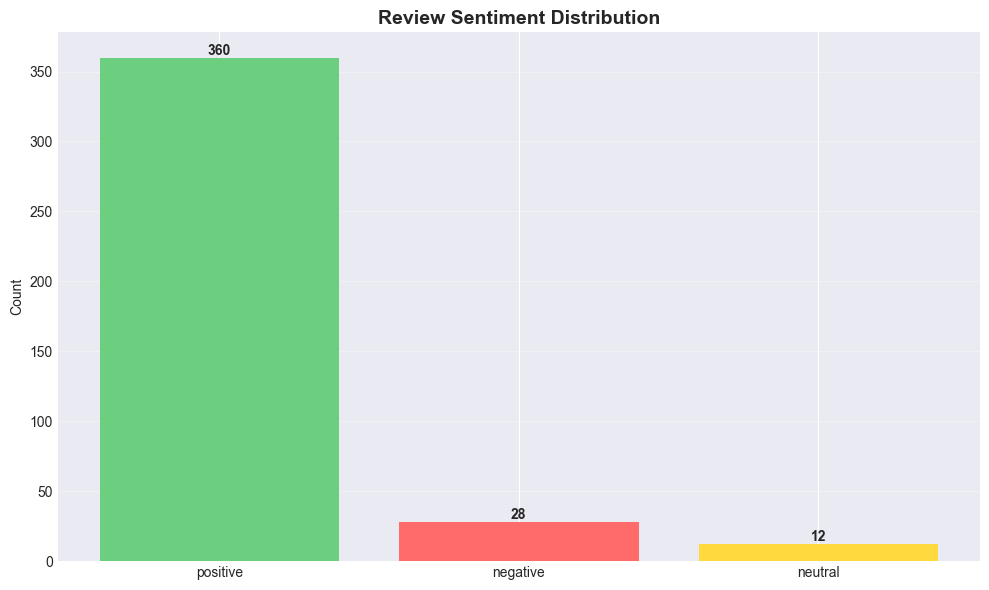

In [3]:
try:
    sentiment_df = pd.read_csv('../ai_models/sentiment_analysis_results.csv')
    sentiment_dist = sentiment_df['sentiment'].value_counts()
    
    plt.figure(figsize=(10, 6))
    colors = {'positive': '#6BCF7F', 'neutral': '#FFD93D', 'negative': '#FF6B6B'}
    bar_colors = [colors[s] for s in sentiment_dist.index]
    
    bars = plt.bar(sentiment_dist.index, sentiment_dist.values, color=bar_colors)
    plt.title('Review Sentiment Distribution', fontsize=14, fontweight='bold')
    plt.ylabel('Count')
    
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., h, f'{int(h)}', 
                ha='center', va='bottom', fontweight='bold')
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
except:
    print('[WARN] Sentiment results not found')